# GRM with PyMC — RWAS dataset

Right-Wing Authoritarianism Scale (Altemeyer 2007) collected by Open Psychometrics (2015).  
**22 items × 9-point Likert scale**, N ≈ 9 680 valid respondents.

This notebook fits the **Graded Response Model** (GRM) with both PyMC 5 and Stan (via PyStan 3),
then compares parameter estimates and sampling efficiency.

## Model

$$
P(u_{ij} \geq k \mid \theta_i, a_j, b_{jk}) = \sigma\!\left(a_j(\theta_i - b_{jk})\right)
$$

Priors: $\theta_i \sim \mathcal{N}(0,1)$, $a_j \sim \text{LogNormal}(0, 0.5)$, $b_{jk} \sim \mathcal{N}(0,1.5)$ (ordered per item).

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import nest_asyncio
nest_asyncio.apply()

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Data

In [2]:
raw = pd.read_csv("./RWAS/data.csv", low_memory=False)
raw

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,screenh,hand,religion,orientation,race,voted,married,familysize,surveyaccurate,major
0,4,1,1,9,3,9,2,7,8,1,...,768,1,4,3,4,1,1,2,1,psychology
1,3,2,1,8,2,7,1,8,9,3,...,1024,1,6,2,4,1,2,3,1,History
2,1,6,7,9,3,9,9,4,9,9,...,800,1,2,1,4,2,1,2,1,NaN
3,1,1,1,8,1,8,1,9,9,1,...,768,1,10,1,4,2,3,3,1,public relations
4,1,1,1,3,1,9,1,1,7,1,...,720,3,2,1,4,1,1,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,8,9,9,9,2,8,1,8,9,5,...,1024,1,6,1,4,1,3,2,1,Social Work
9877,5,2,3,5,2,4,1,9,9,9,...,768,2,4,1,4,2,1,1,1,Aerospace Engineering
9878,4,1,4,9,6,9,2,5,8,3,...,864,1,1,1,5,2,1,1,1,medical sciences MBBS
9879,5,1,1,9,3,9,1,9,9,1,...,900,1,1,1,4,2,1,1,1,Economics


In [3]:
responses = raw.filter(regex="Q\d")
responses.replace({0: pd.NA}, inplace=True)
responses.dropna(inplace=True)
# responses = responses - 1 # 0-index for PyMC
responses

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22
0,4,1,1,9,3,9,2,7,8,1,...,9,1,9,1,1,9,2,9,9,1
1,3,2,1,8,2,7,1,8,9,3,...,9,2,9,1,1,8,1,7,7,1
2,1,6,7,9,3,9,9,4,9,9,...,9,8,9,2,9,3,5,7,9,9
3,1,1,1,8,1,8,1,9,9,1,...,8,1,8,1,1,9,1,9,9,1
4,1,1,1,3,1,9,1,1,7,1,...,9,5,9,1,1,3,1,9,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9876,8,9,9,9,2,8,1,8,9,5,...,8,1,8,2,2,9,2,7,9,2
9877,5,2,3,5,2,4,1,9,9,9,...,3,3,8,7,1,4,3,6,1,6
9878,4,1,4,9,6,9,2,5,8,3,...,8,3,9,1,1,9,3,8,6,2
9879,5,1,1,9,3,9,1,9,9,1,...,9,1,9,1,1,9,1,9,6,1


In [4]:
# 逆転項目
unfav = ["Q4", "Q6", "Q8", "Q9", "Q11", "Q13", "Q15", "Q18", "Q20", "Q21"]

# 逆転前の該当列を確認
display(responses[unfav].head())

# 逆転項目の修正
# 1〜9点尺度なので、10 - score にする
responses[unfav] = 10 - responses[unfav]

display(responses[unfav].head())

,Q4,Q6,Q8,Q9,Q11,Q13,Q15,Q18,Q20,Q21
0,9,9,7,8,9,9,9,9,9,9
1,8,7,8,9,7,9,9,8,7,7
2,9,9,4,9,8,9,9,3,7,9
3,8,8,9,9,9,8,8,9,9,9
4,3,9,1,7,9,9,9,3,9,4


,Q4,Q6,Q8,Q9,Q11,Q13,Q15,Q18,Q20,Q21
0,1,1,3,2,1,1,1,1,1,1
1,2,3,2,1,3,1,1,2,3,3
2,1,1,6,1,2,1,1,7,3,1
3,2,2,1,1,1,2,2,1,1,1
4,7,1,9,3,1,1,1,7,1,6


In [ ]:
use_subsample = False
if use_subsample:
    # Sub-sample for tractable MCMC
    RNG = np.random.default_rng(0)
    N_SAMPLE = 1000
    idx = RNG.choice(len(responses), size=N_SAMPLE, replace=False)
    df_sub = responses.iloc[idx].reset_index(drop=True)
else:
    df_sub = responses

Q_COLS = df_sub.columns.tolist()
N = len(df_sub)           # respondents
J = len(df_sub.columns)           # items
K = 9                     # categories

# 0-indexed for PyMC  (0 … K-1)
Y0 = df_sub.values.astype(int) - 1   # shape (N, J)
# 1-indexed for Stan  (1 … K)
Y1 = df_sub.values.astype(int)        # shape (N, J)

print(f"Sub-sample: N={N}, J={J}, K={K}")
print(f"Response range (0-indexed): [{Y0.min()}, {Y0.max()}]")

Sub-sample: N=1000, J=22, K=9
Response range (0-indexed): [0, 8]


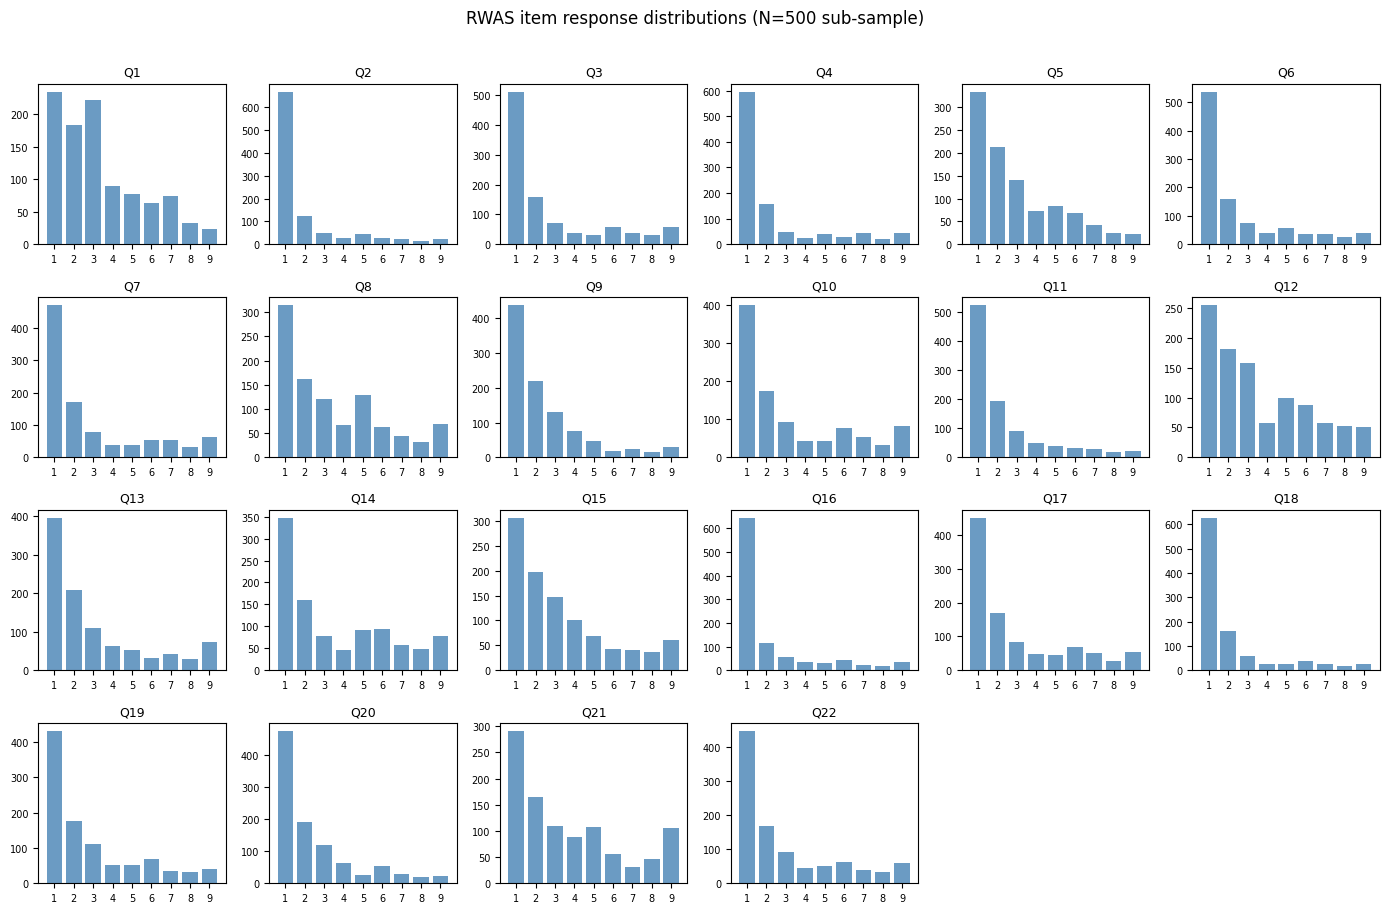

In [24]:
fig, axes = plt.subplots(4, 6, figsize=(14, 9), sharey=False)
for ax, col in zip(axes.ravel(), Q_COLS):
    counts = np.bincount(Y1[:, Q_COLS.index(col)], minlength=K + 1)[1:]
    ax.bar(range(1, K + 1), counts, color="steelblue", alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xticks(range(1, K + 1))
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[J:]:
    ax.set_visible(False)
plt.suptitle("RWAS item response distributions (N=500 sub-sample)", y=1.01)
plt.tight_layout()
plt.show()

## PyMC

Ordered thresholds are parameterised via cumulative sum of positive increments to avoid the
`-inf` initialisation issue that arises when `transform=ordered` is applied to a 2-D `Normal`.

https://www.pymc.io/projects/examples/en/latest/generalized_linear_models/GLM-ordinal-regression.html

数式に合わせて ` cutpoints = a[:, None] * b` にするとaとbに相関が出てサンプリングしにくいかもしれない

In [43]:
# Flatten (N, J) → (N*J,) with respondent / item index vectors
person_idx = np.repeat(np.arange(N), J)   # (N*J,)
item_idx   = np.tile(np.arange(J), N)     # (N*J,)
obs_flat   = Y0.ravel()                   # (N*J,), 0-indexed

t0_pymc = time.perf_counter()

with pm.Model() as grm_pymc:
    theta = pm.Normal("theta", 0.0, 1.0, shape=N)
    a = pm.LogNormal("a", 0.0, 1.0, shape=J)
    b = pm.Normal(
        "b",
        # mu=np.linspace(-2, 2, K - 1),
        mu=0.0,
        sigma=2.0,
        transform=pm.distributions.transforms.ordered,
        initval=np.tile(np.linspace(-2, 2, K - 1), (J, 1)),
        shape=(J, K - 1),
    )
    # cutpoints c_{jk} = a_j * b_{jk}
    c = pm.Deterministic("cutpoints", a[:, None] * b)

    # Linear predictor: eta_{ij} = a_j * theta_i
    eta = a[item_idx] * theta[person_idx]  # (N*J,)

    pm.OrderedLogistic(
        "Y_obs",
        eta=eta,
        cutpoints=c[item_idx],  # (N*J, K-1)
        observed=obs_flat,
        compute_p=False,
    )

    idata_pymc = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        nuts_sampler="numpyro",
    )

t1_pymc = time.perf_counter()
time_pymc = t1_pymc - t0_pymc
print(f"PyMC sampling time: {time_pymc / 60:.1f} minutes")
# pm.model_to_graphviz(grm_pymc)

Compiling.. :   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4000 [00:00<?, ?it/s]





Running chain 0:   5%|▌         | 200/4000 [00:13<03:59, 15.85it/s]


Running chain 0:  15%|█▌        | 600/4000 [00:23<01:51, 30.52it/s]




Running chain 0:  20%|██        | 800/4000 [00:28<01:36, 33.00it/s]


Running chain 0:  25%|██▌       | 1000/4000 [00:33<01:28, 34.09it/s]


Running chain 0:  30%|███       | 1200/4000 [00:38<01:17, 36.26it/s]


Running chain 0:  35%|███▌      | 1400/4000 [00:43<01:09, 37.14it/s]


Running chain 0:  40%|████      | 1600/4000 [00:49<01:03, 37.65it/s]


Running chain 0:  45%|████▌     | 1800/4000 [00:54<00:59, 37.11it/s]


Running chain 0:  50%|█████     | 2000/4000 [00:59<00:53, 37.45it/s]


Running chain 0:  55%|█████▌    | 2200/4000 [01:05<00:48, 37.02it/s]


Running chain 0:  60%|██████    | 2400/4000 [01:11<00:44, 36.02it/s]


Running chain 0:  65%|██████▌   | 2600/4000 [01:16<00:38, 36.24it/s]


Running chain 0:  70%|████

PyMC sampling time: 2.0 minutes


In [8]:
summary = az.summary(
    idata_pymc,
    var_names=["a", "cutpoints", "b", "theta"],
    round_to=3,
)
bad = summary.query("r_hat > 1.01").copy()
bad["kind"] = bad.index.to_series().str.extract(r"^([a-zA-Z_]+)")[0]
bad.groupby("kind")["r_hat"].agg(["count", "max", "mean"])

,count,max,mean
kind,,,


In [9]:
import os
os.makedirs("./results", exist_ok=True)

a_mean = idata_pymc.posterior["a"].mean(dim=["chain", "draw"]).values  # (J,)
b_mean = idata_pymc.posterior["b"].mean(dim=["chain", "draw"]).values  # (J, K-1)

rows = []
for j in range(J):
    row = {"item": Q_COLS[j], "a": a_mean[j]}
    for k in range(K - 1):
        row[f"b{k+1}"] = b_mean[j, k]
    rows.append(row)

pymc_params = pd.DataFrame(rows)
display(pymc_params)

if not use_subsample:
    pymc_params.to_csv("./results/pymc_params.csv", index=False)
    print("Saved to ./results/pymc_params.csv")


,item,a,b1,b2,b3,b4,b5,b6,b7,b8
0,Q1,1.559107,-1.100610,-0.239656,0.471761,0.778299,1.203021,1.672806,2.415545,3.200729
1,Q2,2.424191,0.458616,0.935490,1.187073,1.329341,1.582292,1.861197,2.140947,2.482920
2,Q3,3.016828,0.022715,0.488816,0.729889,0.864530,1.034763,1.296487,1.539298,1.849181
3,Q4,2.479475,0.209696,0.730567,0.974641,1.072745,1.295422,1.532780,1.823020,2.106318
4,Q5,1.903294,-0.635024,0.116369,0.668782,1.003818,1.375142,1.824558,2.301429,2.909047
5,Q6,1.899908,0.041029,0.617993,0.974049,1.162423,1.527890,1.813017,2.136011,2.526267
6,Q7,3.287657,-0.150327,0.372476,0.650386,0.830058,0.970196,1.232740,1.509765,1.828536
7,Q8,1.569452,-0.755836,-0.067909,0.461512,0.693585,1.277204,1.639005,2.039749,2.446924
8,Q9,1.871144,-0.242799,0.534855,1.068188,1.539299,1.831677,2.088552,2.375251,2.755514
9,Q10,3.275973,-0.309761,0.188728,0.464672,0.626812,0.819080,1.129217,1.396360,1.756481


Saved to ./results/pymc_params.csv


In [10]:
theta_mean = idata_pymc.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
theta_df = pd.DataFrame({"person": np.arange(N), "theta": theta_mean})
display(theta_df.head())

if not use_subsample:
    theta_df.to_csv("./results/pymc_theta.csv", index=False)
    print("Saved to ./results/pymc_theta.csv")

,person,theta
0,0,-0.670611
1,1,-0.131365
2,2,1.092906
3,3,-0.830811
4,4,-0.481785


Saved to ./results/pymc_theta.csv
